<a href="https://colab.research.google.com/github/HamzaEric/Protein_Localization_MLP/blob/main/Noteooks/Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import random
import torch.optim as optim
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Optimization

Optimization in neural networks is the process of iteratively adjusting a model's weights and biases to minimize the error between its predictions and the actual targets.

Gradient descent is the fundamental engine that drives learning in almost all neural networks.

| Method               | How Gradient is Computed                 | Speed      | Stability | Memory |
|----------------------|------------------------------------------|------------|-----------|--------|
| **Batch Gradient Descent** | Use the **entire dataset** to compute gradient | Slow        | Stable    | High   |
| **Stochastic Gradient Descent (SGD)** | Use **1 random sample** at a time           | Fast updates | Noisy     | Low    |
| **Mini-batch SGD**   | Use **a few samples (batch)**            | Good tradeoff | Balanced  | Medium |


## The fundamental difference between these three variants comes down to a single question: How much data do we process before updating the model's weights?

In [6]:
df = pd.read_csv("/content/drive/MyDrive/yeast.csv")
df.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,localization_site
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


In [7]:
X = df.drop("localization_site", axis=1)
y = df["localization_site"]

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(class_names)

['CYT' 'ERL' 'EXC' 'ME1' 'ME2' 'ME3' 'MIT' 'NUC' 'POX' 'VAC']


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

In [10]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


print("Train set:", X_train_tensor.shape)
print("Test set:", X_test_tensor.shape)


Train set: torch.Size([1187, 8])
Test set: torch.Size([297, 8])


In [11]:
CT_class_counts = torch.bincount(y_train_tensor)
print("CT_Class Distribution:")
for i, count in enumerate(CT_class_counts):
    print(f"Class {i}: {count.item()}")

CT_Class Distribution:
Class 0: 370
Class 1: 4
Class 2: 28
Class 3: 35
Class 4: 41
Class 5: 131
Class 6: 195
Class 7: 343
Class 8: 16
Class 9: 24


# MLP Building


In [12]:
class YeastMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(YeastMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# Instantiate the model
input_dim = X_train_tensor.shape[1]      # 8 features
hidden_dim = 16
output_dim = len(class_names)            # 10 classes

model = YeastMLP(input_dim, hidden_dim, output_dim)


print(model)


YeastMLP(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=10, bias=True)
  )
)


# Variants Of Gradient Descent

Gradient descent is a optimization algorithm in machine learning used to minimize functions by iteratively moving towards the minimum.

## 1. Batch Gradient Descent

Batch Gradient Descent is a variant of the gradient descent algorithm where the entire dataset is used to compute the gradient of the loss function with respect to the parameters.

In each iteration the algorithm calculates the average gradient of the loss function for all the training examples and updates the model parameters accordingly.

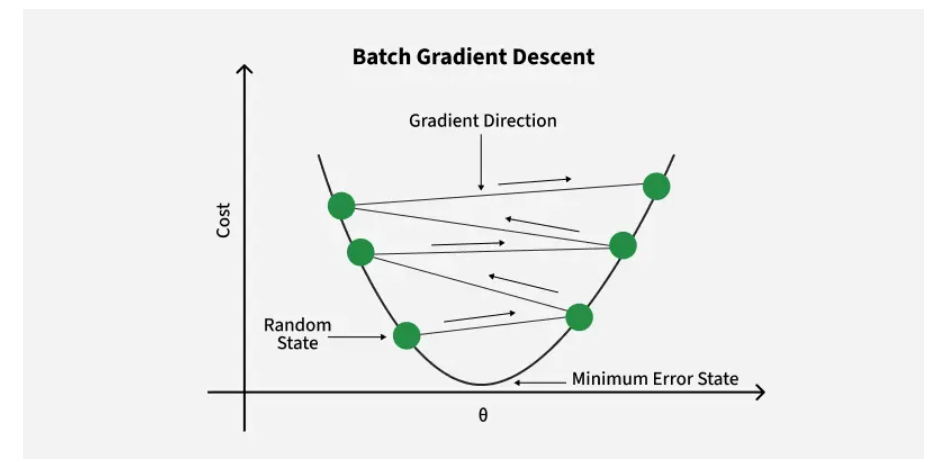

The update rule for batch gradient descent is:

$$
\theta = \theta - \eta \nabla J(\theta)
$$

where:

- $\theta$ represents the parameters of the model.
- $\eta$ is the learning rate.
- $\nabla J(\theta)$ is the gradient of the loss function $J(\theta)$ with respect to $\theta$.

## 2. Stochastic Gradient Descent
Stochastic Gradient Descent (SGD) is a variant of the gradient descent algorithm where the model parameters are updated using the gradient of the loss function with respect to a single training example at each iteration.

Unlike batch gradient descent which uses the entire dataset SGD updates the parameters more frequently, leading to faster convergence.

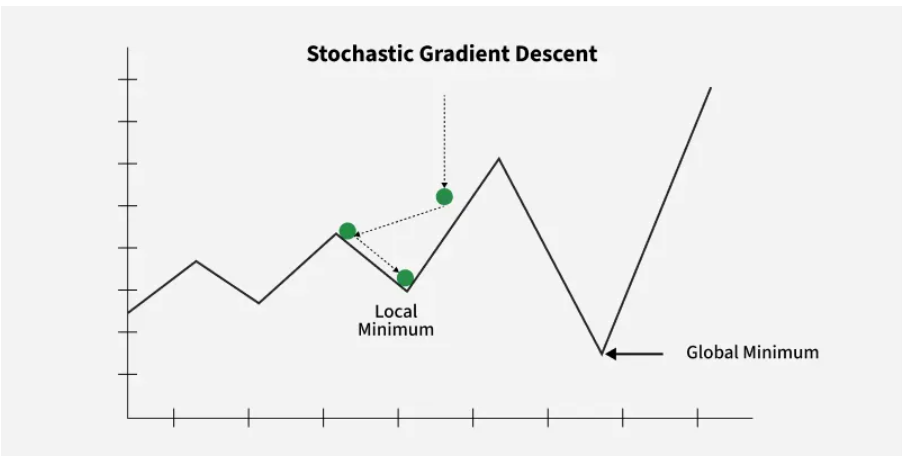

The update rule for SGD is:

$$
\theta = \theta - \eta \nabla J\left(\theta; x^{(i)}, y^{(i)}\right)
$$

where:

- $\theta$ represents the parameters of the model.
- $\eta$ is the learning rate.
- $\nabla J\left(\theta; x^{(i)}, y^{(i)}\right)$ is the gradient of the loss function $J(\theta)$ with respect to $\theta$ for the $i$th training example $\left(x^{(i)}, y^{(i)}\right)$.

## 3. Mini-Batch Gradient Descent

Mini-Batch Gradient Descent is a compromise between Batch Gradient Descent and Stochastic Gradient Descent.

Instead of using the entire dataset or a single training example Mini-Batch Gradient Descent updates the model parameters using a small, random subset of the training data called a mini-batch.

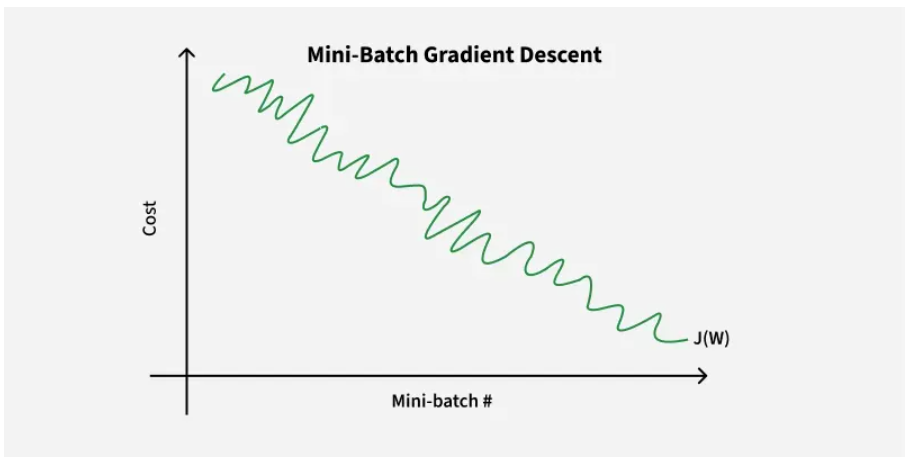

The update rule for Mini-Batch Gradient Descent is:

$$
\theta = \theta - \eta \nabla J\left(\theta; \left\{x^{(i)}, y^{(i)}\right\}_{i=1}^{m}\right)
$$

where:

- $\theta$ represents the parameters of the model.
- $\eta$ is the learning rate.
- $\left\{x^{(i)}, y^{(i)}\right\}_{i=1}^{m}$ represents a mini-batch of $m$ training examples.
- $\nabla J\left(\theta; \left\{x^{(i)}, y^{(i)}\right\}_{i=1}^{m}\right)$ is the gradient of the loss function $J(\theta)$ with respect to $\theta$ for the mini-batch.



# Full Batch Gradient Descent



In [13]:
model_gd = YeastMLP(input_dim, hidden_dim, output_dim)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_gd.parameters(), lr=0.1)

# Store loss and accuracy per epoch
train_loss_gd = []
train_acc_gd = []

# Training loop - full batch GD
n_epochs = 100

start_time = time.perf_counter()

for epoch in range(n_epochs):
    # Set model to training mode
    model_gd.train()

    # Forward pass on the whole training set
    logits = model_gd(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Store loss
    train_loss_gd.append(loss.item())

    # Compute accuracy
    preds = torch.argmax(logits, dim=1)
    acc = (preds == y_train_tensor).float().mean().item()
    train_acc_gd.append(acc)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>2} | Loss: {loss.item():.4f} | Accuracy: {acc*100:.2f}%")

end_time = time.perf_counter()
print(f"Training completed in {end_time - start_time:.2f} seconds")

Epoch 10 | Loss: 2.0822 | Accuracy: 34.46%
Epoch 20 | Loss: 1.8964 | Accuracy: 37.99%
Epoch 30 | Loss: 1.7565 | Accuracy: 38.84%
Epoch 40 | Loss: 1.6477 | Accuracy: 40.52%
Epoch 50 | Loss: 1.5601 | Accuracy: 43.30%
Epoch 60 | Loss: 1.4865 | Accuracy: 48.19%
Epoch 70 | Loss: 1.4225 | Accuracy: 51.56%
Epoch 80 | Loss: 1.3666 | Accuracy: 52.49%
Epoch 90 | Loss: 1.3188 | Accuracy: 54.00%
Epoch 100 | Loss: 1.2791 | Accuracy: 54.76%
Training completed in 0.16 seconds


In [14]:
CT_model_gd = YeastMLP(input_dim, hidden_dim, output_dim)
CT_loss_fn = nn.CrossEntropyLoss()
CT_optimizer = torch.optim.Adam(CT_model_gd.parameters(), lr=0.001)

# Forward pass
CT_logits = CT_model_gd(X_train_tensor)
CT_loss = CT_loss_fn(CT_logits, y_train_tensor)

# Backward pass
CT_optimizer.zero_grad()
CT_loss.backward()
CT_optimizer.step()

# Accuracy
CT_preds = torch.argmax(CT_logits, dim=1)
CT_acc = (CT_preds == y_train_tensor).sum().item() / len(y_train_tensor)

print(f"CT_OneEpoch Loss: {CT_loss.item():.4f}")
print(f"CT_OneEpoch Accuracy: {CT_acc:.4f}")


CT_OneEpoch Loss: 2.4499
CT_OneEpoch Accuracy: 0.0253


# Stochastic Gradient Descent

In [15]:
model_sgd = YeastMLP(input_dim=8, hidden_dim=16, output_dim=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_sgd.parameters(), lr=0.01)

# Track metrics
sgd_loss_values = []
sgd_accuracy_values = []

# Convert train set into list of samples
train_samples = list(zip(X_train_tensor, y_train_tensor))

start_time = time.perf_counter()

# Training loop: SGD
for epoch in range(100):
    epoch_loss = 0
    correct = 0

    # Shuffle training samples
    torch.random.manual_seed(epoch)  # Ensures reproducibility across epochs
    shuffled_samples = train_samples.copy()
    random.shuffle(shuffled_samples)

    for x_sample, y_sample in shuffled_samples:
        x_sample = x_sample.unsqueeze(0)  # add batch dim
        y_sample = y_sample.unsqueeze(0)

        # Forward pass
        outputs = model_sgd(x_sample)
        loss = criterion(outputs, y_sample)

        # Backprop + Update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == y_sample).sum().item()

    avg_loss = epoch_loss / len(train_samples)
    accuracy = correct / len(train_samples)

    sgd_loss_values.append(avg_loss)
    sgd_accuracy_values.append(accuracy)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>2} | Loss: {avg_loss:.4f} | Accuracy: {accuracy*100:.2f}%")

end_time = time.perf_counter()
print(f"Training completed in {end_time - start_time:.2f} seconds")

Epoch 10 | Loss: 1.0271 | Accuracy: 60.49%
Epoch 20 | Loss: 1.0026 | Accuracy: 61.50%
Epoch 30 | Loss: 0.9870 | Accuracy: 61.92%
Epoch 40 | Loss: 0.9775 | Accuracy: 62.76%
Epoch 50 | Loss: 0.9642 | Accuracy: 61.92%
Epoch 60 | Loss: 0.9557 | Accuracy: 64.20%
Epoch 70 | Loss: 0.9530 | Accuracy: 63.86%
Epoch 80 | Loss: 0.9394 | Accuracy: 63.02%
Epoch 90 | Loss: 0.9382 | Accuracy: 65.29%
Epoch 100 | Loss: 0.9394 | Accuracy: 63.69%
Training completed in 67.86 seconds


# Mini-Batch SGD

In [16]:
batch_size = 32
epochs = 100
learning_rate = 0.01

# Re-initialize model and optimizer
model_mb = YeastMLP(input_dim, hidden_dim, output_dim)
optimizer_mb = optim.SGD(model_mb.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Create DataLoader for mini-batch SGD
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Store metrics
losses_mb = []
accs_mb = []

start_time = time.perf_counter()

# Training loop
for epoch in range(epochs):
    model_mb.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model_mb(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass
        optimizer_mb.zero_grad()
        loss.backward()
        optimizer_mb.step()

        # Track loss
        epoch_loss += loss.item() * X_batch.size(0)

        # Track accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    avg_loss = epoch_loss / total
    acc = correct / total

    losses_mb.append(avg_loss)
    accs_mb.append(acc)

    print(f"[Mini-Batch] Epoch {epoch+1:2d}: Loss = {avg_loss:.4f} | Accuracy = {acc:.4f}")

end_time = time.perf_counter()
print(f"Training completed in {end_time - start_time:.2f} seconds")


[Mini-Batch] Epoch  1: Loss = 2.3657 | Accuracy = 0.0666
[Mini-Batch] Epoch  2: Loss = 2.2366 | Accuracy = 0.2477
[Mini-Batch] Epoch  3: Loss = 2.1264 | Accuracy = 0.3260
[Mini-Batch] Epoch  4: Loss = 2.0301 | Accuracy = 0.3463
[Mini-Batch] Epoch  5: Loss = 1.9436 | Accuracy = 0.3547
[Mini-Batch] Epoch  6: Loss = 1.8653 | Accuracy = 0.3488
[Mini-Batch] Epoch  7: Loss = 1.7980 | Accuracy = 0.3614
[Mini-Batch] Epoch  8: Loss = 1.7373 | Accuracy = 0.3724
[Mini-Batch] Epoch  9: Loss = 1.6837 | Accuracy = 0.3732
[Mini-Batch] Epoch 10: Loss = 1.6380 | Accuracy = 0.3850
[Mini-Batch] Epoch 11: Loss = 1.5972 | Accuracy = 0.4078
[Mini-Batch] Epoch 12: Loss = 1.5633 | Accuracy = 0.4212
[Mini-Batch] Epoch 13: Loss = 1.5322 | Accuracy = 0.4313
[Mini-Batch] Epoch 14: Loss = 1.5044 | Accuracy = 0.4423
[Mini-Batch] Epoch 15: Loss = 1.4797 | Accuracy = 0.4507
[Mini-Batch] Epoch 16: Loss = 1.4571 | Accuracy = 0.4575
[Mini-Batch] Epoch 17: Loss = 1.4359 | Accuracy = 0.4591
[Mini-Batch] Epoch 18: Loss = 1

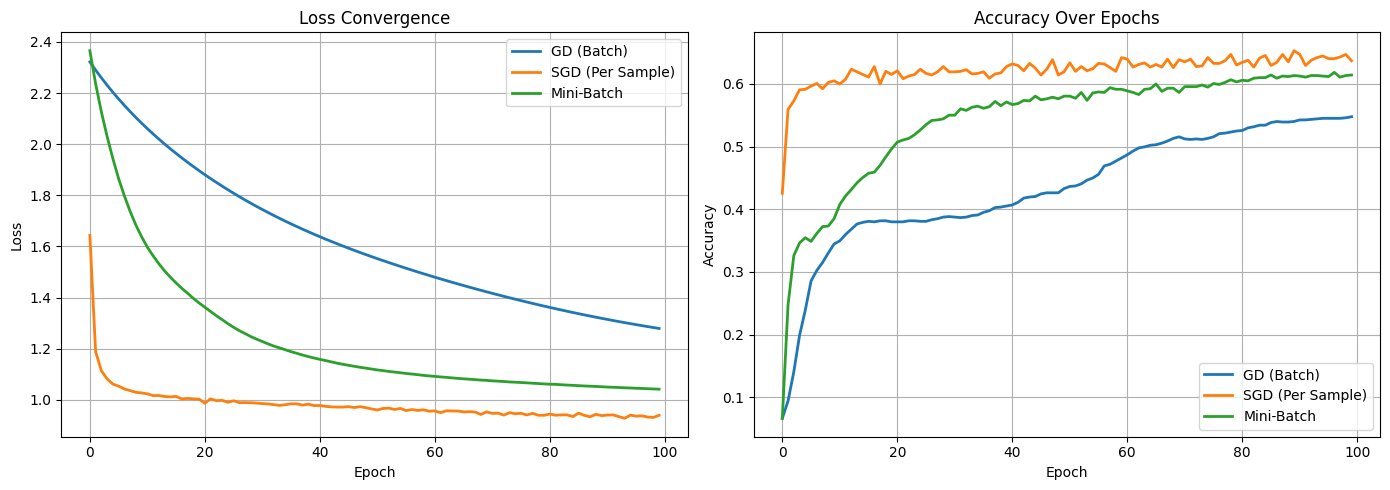

In [17]:
epochs = len(train_loss_gd)  # assuming all lists are same length

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_loss_gd, label="GD (Batch)", linewidth=2)
plt.plot(range(epochs), sgd_loss_values, label="SGD (Per Sample)", linewidth=2)
plt.plot(range(epochs), losses_mb, label="Mini-Batch", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Convergence")
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(epochs), train_acc_gd, label="GD (Batch)", linewidth=2)
plt.plot(range(epochs), sgd_accuracy_values, label="SGD (Per Sample)", linewidth=2)
plt.plot(range(epochs), accs_mb, label="Mini-Batch", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

>Interpretation of the Graphs Above

- **Loss Convergence**:
  - **SGD (Per Sample)** shows the **fastest loss drop** initially, but the curve is noisy.
  - **Mini-Batch SGD** shows a **smooth and fast** descent, balancing speed and stability.
  - **Full-Batch GD** converges steadily but slowly — its updates are too infrequent for quick learning.

- **Accuracy Over Epochs**:
  - SGD achieves high accuracy **early** but shows **fluctuations** due to its noisy nature.
  - Mini-Batch SGD provides **consistent and steadily improving accuracy**.
  - Full-Batch GD improves slowly and reaches **lower final accuracy** than the other two.

> Key Insight

- **Mini-Batch SGD** offers the best compromise:
  - Efficient GPU usage
  - Stable gradients
  - Faster convergence than Batch GD
  - Smoother than per-sample SGD

✅ Test Accuracy (Gradient Descent (Batch)): 0.5690


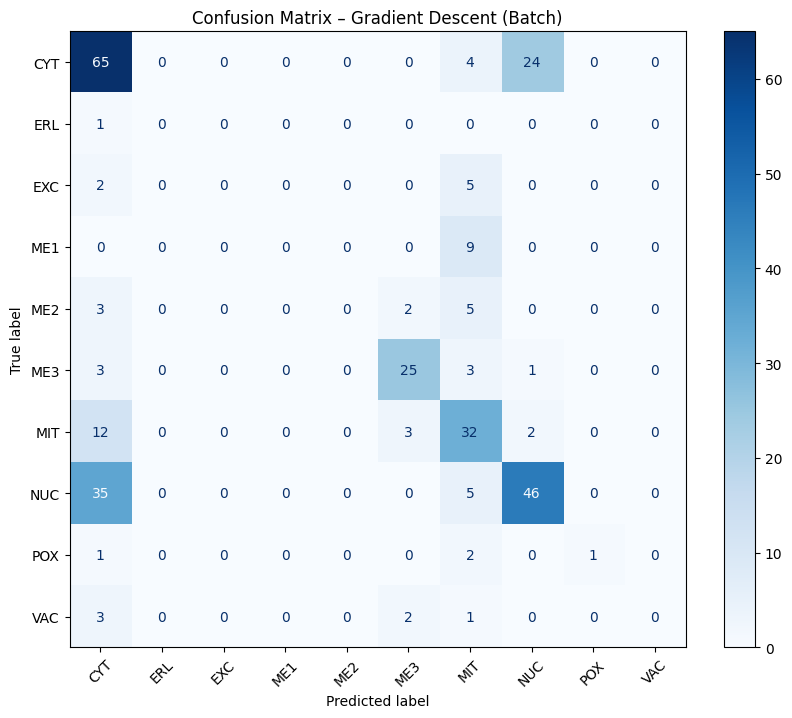

✅ Test Accuracy (Stochastic Gradient Descent (Per Sample)): 0.5623


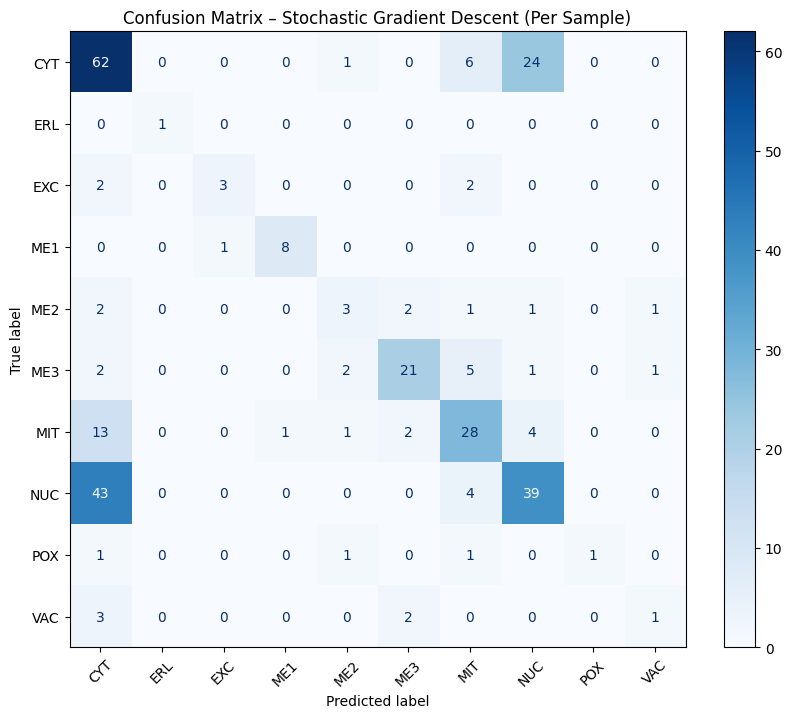

✅ Test Accuracy (Mini-Batch SGD): 0.5993


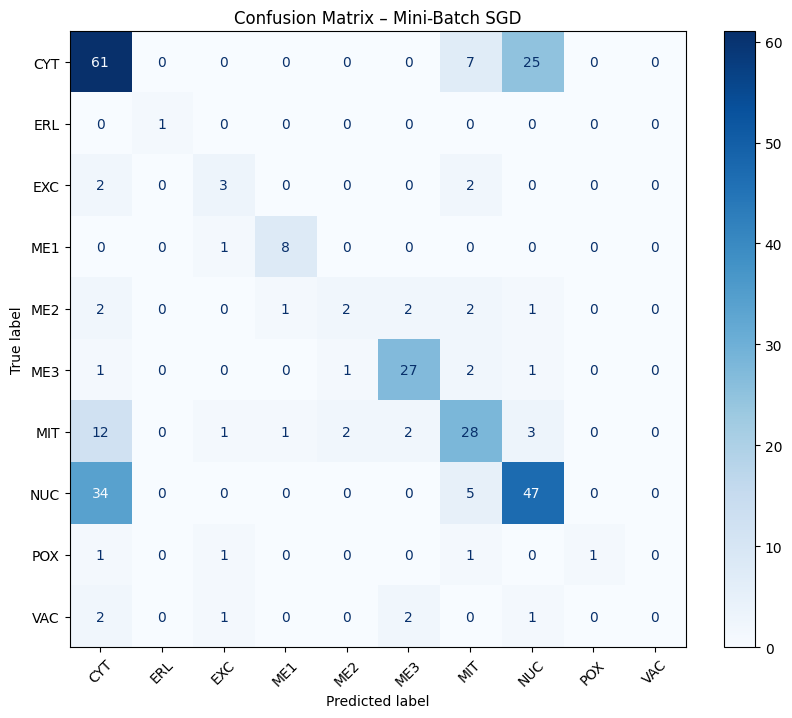

In [19]:
def evaluate_model(model, X_test, y_test, class_names, title):
    # Put model in eval mode
    model.eval()

    # Disable gradient tracking
    with torch.no_grad():
        outputs = model(X_test)
        _, preds = torch.max(outputs, 1)  # get predicted class indices

    # Convert to numpy for sklearn
    y_true = y_test.cpu().numpy()
    y_pred = preds.cpu().numpy()

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"✅ Test Accuracy ({title}): {acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix – {title}")
    plt.show()

# Evaluate all models
evaluate_model(model_gd, X_test_tensor, y_test_tensor, class_names, "Gradient Descent (Batch)")
evaluate_model(model_sgd, X_test_tensor, y_test_tensor, class_names, "Stochastic Gradient Descent (Per Sample)")
evaluate_model(model_mb, X_test_tensor, y_test_tensor, class_names, "Mini-Batch SGD")